# Анализ результатов A/B-теста образовательного Telegram-бота

Цель анализа — сравнить контрольную и тестовую версии бота по прохождению урока, результатам заданий и субъективной оценке взаимодействия после урока.

Основная гипотеза: тестовая версия бота улучшает пользовательский опыт по сравнению с контрольной. Основная survey-метрика — средняя оценка пользователя по 8 вопросам анкеты. Дополнительно проверяется более узкая метрика по вопросам 1, 2 и 7: поддержка, приятность взаимодействия и дружелюбность бота.


## 1. Загрузка данных и настройки

Используются файлы с суффиксом `_2`, лежащие в той же папке, что и ноутбук. Аккаунты `426826357` и `420252802` исключаются из анализа, потому что это тестовые аккаунты, использовавшиеся при разработке.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import TTestIndPower

DATA_DIR = Path('.')
USERS_PATH = DATA_DIR / 'users_2.csv'
SURVEY_PATH = DATA_DIR / 'survey_answers_2.csv'
ANSWERS_PATH = DATA_DIR / 'answers_2.csv'
EVENTS_PATH = DATA_DIR / 'events_2.csv'
COMMENTS_PATH = DATA_DIR / 'survey_open_comments_2.csv'

# Тестовые аккаунты, использовавшиеся при разработке. В исследовательскую выборку не входят.
TEST_ACCOUNT_IDS = [426826357, 420252802]

plt.style.use('default')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)


In [2]:
users_raw = pd.read_csv(USERS_PATH)
survey_raw = pd.read_csv(SURVEY_PATH)
answers_raw = pd.read_csv(ANSWERS_PATH)
events_raw = pd.read_csv(EVENTS_PATH)
comments_raw = pd.read_csv(COMMENTS_PATH)

print('users:', users_raw.shape)
print('survey answers:', survey_raw.shape)
print('lesson answers:', answers_raw.shape)
print('events:', events_raw.shape)
print('open comments:', comments_raw.shape)

users_raw.head()


users: (86, 13)
survey answers: (616, 6)
lesson answers: (476, 7)
events: (4834, 5)
open comments: (26, 4)


,id,telegram_id,username,group,gender,age_group,art_experience,created_at,lesson_started_at,lesson_completed_at,survey_started_at,survey_completed_at,correct_answers_count
0,1,420252802,malmarie,control,female,20_29,sometimes,2026-03-01T13:15:50.895197+00:00,2026-04-03T13:28:52.454683+00:00,2026-04-03T13:29:24.041937+00:00,2026-04-03T13:29:27.091936+00:00,2026-04-03T13:29:40.926663+00:00,3
1,2,426826357,alkirill,test,male,under_20,almost_none,2026-03-01T13:18:37.505905+00:00,2026-04-02T20:30:33.329018+00:00,2026-04-02T20:31:26.674607+00:00,2026-04-02T20:31:32.425901+00:00,2026-04-02T20:31:42.372758+00:00,3
2,3,986873061,savvatoms,test,male,20_29,almost_none,2026-04-02T08:04:30.070160+00:00,2026-04-02T08:05:12.245434+00:00,2026-04-02T08:12:58.926970+00:00,2026-04-02T08:13:11.243443+00:00,2026-04-02T08:13:49.262975+00:00,6
3,4,521726009,Elena_Malkova14,control,female,40_plus,sometimes,2026-04-02T10:34:28.137469+00:00,2026-04-02T10:34:45.910204+00:00,2026-04-02T10:39:33.058123+00:00,2026-04-02T10:39:48.501971+00:00,2026-04-02T10:40:52.130481+00:00,6
4,5,894848749,tatianatako,control,female,20_29,sometimes,2026-04-02T13:11:47.112069+00:00,2026-04-02T13:12:58.907509+00:00,2026-04-02T13:18:25.739087+00:00,2026-04-02T13:18:41.942895+00:00,2026-04-02T13:20:04.555441+00:00,6


## 2. Подготовка данных

Даты и числовые поля приводятся к нужным типам, создаются флаги прохождения этапов и рассчитываются длительности. Если из-за технических ошибок логирования появляются отрицательные длительности, они заменяются на пропуски.


In [3]:
def prepare_users(users: pd.DataFrame, exclude_ids) -> pd.DataFrame:
    df = users.copy()
    df.columns = df.columns.str.strip()
    df = df[~df['telegram_id'].isin(exclude_ids)].copy()

    date_cols = [
        'created_at',
        'lesson_started_at',
        'lesson_completed_at',
        'survey_started_at',
        'survey_completed_at',
    ]
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], errors='coerce')

    df['is_registered'] = df['created_at'].notna()
    df['started_lesson'] = df['lesson_started_at'].notna()
    df['completed_lesson'] = df['lesson_completed_at'].notna()
    df['started_survey'] = df['survey_started_at'].notna()
    df['completed_survey'] = df['survey_completed_at'].notna()

    df['lesson_duration_sec'] = (df['lesson_completed_at'] - df['lesson_started_at']).dt.total_seconds()
    df['survey_duration_sec'] = (df['survey_completed_at'] - df['survey_started_at']).dt.total_seconds()
    df['full_flow_duration_sec'] = (df['survey_completed_at'] - df['lesson_started_at']).dt.total_seconds()

    for col in ['lesson_duration_sec', 'survey_duration_sec', 'full_flow_duration_sec']:
        df.loc[df[col] < 0, col] = np.nan

    return df


def prepare_survey(survey: pd.DataFrame, exclude_ids) -> pd.DataFrame:
    df = survey.copy()
    df.columns = df.columns.str.strip()
    df['answered_at'] = pd.to_datetime(df['answered_at'], errors='coerce')
    df['survey_question_number'] = pd.to_numeric(df['survey_question_number'], errors='coerce')
    df['selected_option'] = pd.to_numeric(df['selected_option'], errors='coerce')
    df['telegram_id'] = pd.to_numeric(df['telegram_id'], errors='coerce')

    df = df[~df['telegram_id'].isin(exclude_ids)].copy()
    df = df[df['survey_question_number'].between(1, 8)].copy()
    df = df.dropna(subset=['telegram_id', 'survey_question_number', 'answered_at', 'selected_option']).copy()
    df = df.sort_values(['telegram_id', 'answered_at']).copy()

    # Новая попытка начинается каждый раз, когда пользователь отвечает на вопрос 1.
    df['is_q1'] = (df['survey_question_number'] == 1).astype(int)
    df['attempt_n'] = df.groupby('telegram_id')['is_q1'].cumsum()
    df = df[df['attempt_n'] > 0].copy()

    return df

users = prepare_users(users_raw, TEST_ACCOUNT_IDS)
survey = prepare_survey(survey_raw, TEST_ACCOUNT_IDS)

print('Пользователей после исключения тестовых аккаунтов:', users.shape[0])
print(users['group'].value_counts(dropna=False))


Пользователей после исключения тестовых аккаунтов: 84
group
test       42
control    42
Name: count, dtype: int64


## 3. Общий обзор выборки

После удаления тестовых аккаунтов в выборке остаётся 84 пользователя: по 42 в контрольной и тестовой группах. Это удобно для сравнения, но выборка всё равно небольшая для обнаружения слабых эффектов.


In [4]:
print('=== Пропуски в users ===')
print(users.isna().sum().sort_values(ascending=False))

print('\n=== Распределение по группам ===')
print(users['group'].value_counts(dropna=False))

print('\n=== Распределение по полу ===')
print(users['gender'].value_counts(dropna=False))

print('\n=== Распределение по возрасту ===')
print(users['age_group'].value_counts(dropna=False))

print('\n=== Распределение по опыту в искусстве ===')
print(users['art_experience'].value_counts(dropna=False))


=== Пропуски в users ===
full_flow_duration_sec    21
survey_duration_sec       21
survey_completed_at       21
lesson_completed_at       20
lesson_duration_sec       20
survey_started_at         20
art_experience             4
lesson_started_at          4
age_group                  2
gender                     2
created_at                 0
telegram_id                0
correct_answers_count      0
is_registered              0
started_lesson             0
completed_lesson           0
started_survey             0
completed_survey           0
group                      0
username                   0
id                         0
dtype: int64

=== Распределение по группам ===
group
test       42
control    42
Name: count, dtype: int64

=== Распределение по полу ===
gender
female     52
male       29
NaN         2
unknown     1
Name: count, dtype: int64

=== Распределение по возрасту ===
age_group
under_20    35
20_29       33
40_plus      8
30_39        6
NaN          2
Name: count, dtype:

In [5]:
funnel_summary = pd.DataFrame({
    'users': [
        len(users),
        users['started_lesson'].sum(),
        users['completed_lesson'].sum(),
        users['started_survey'].sum(),
        users['completed_survey'].sum(),
    ]
}, index=['all_users', 'lesson_started', 'lesson_completed', 'survey_started', 'survey_completed'])

funnel_summary['conversion_from_all'] = funnel_summary['users'] / len(users)
funnel_summary['conversion_from_prev'] = funnel_summary['users'] / funnel_summary['users'].shift(1)
funnel_summary.loc['all_users', 'conversion_from_prev'] = 1.0

funnel_summary.round(3)


,users,conversion_from_all,conversion_from_prev
all_users,84,1.000,1.000
lesson_started,80,0.952,0.952
lesson_completed,64,0.762,0.800
survey_started,64,0.762,1.000
survey_completed,63,0.750,0.984


In [6]:
group_summary = users.groupby('group').agg(
    users=('id', 'count'),
    female_share=('gender', lambda x: (x == 'female').mean()),
    lesson_start_rate=('started_lesson', 'mean'),
    lesson_completion_rate=('completed_lesson', 'mean'),
    survey_completion_rate=('completed_survey', 'mean'),
    avg_correct_answers=('correct_answers_count', 'mean'),
    median_correct_answers=('correct_answers_count', 'median'),
    median_lesson_duration_sec=('lesson_duration_sec', 'median'),
    median_survey_duration_sec=('survey_duration_sec', 'median'),
).round(3)

group_summary


,users,female_share,lesson_start_rate,lesson_completion_rate,survey_completion_rate,avg_correct_answers,median_correct_answers,median_lesson_duration_sec,median_survey_duration_sec
group,,,,,,,,,
control,42,0.595,0.952,0.738,0.738,4.262,6.0,204.360,41.528
test,42,0.643,0.952,0.786,0.762,4.381,6.0,175.453,39.077


## 4. Баланс групп

Размеры групп равны, однако по некоторым характеристикам есть отличия. Например, в тестовой группе больше пользователей с опытом `almost_none`, а в контрольной — больше пользователей с опытом `sometimes`. Это важно учитывать как ограничение: предварительный опыт может влиять на восприятие урока и взаимодействия с ботом.


In [7]:
def balance_table(data: pd.DataFrame, segment_col: str):
    counts = pd.crosstab(data[segment_col], data['group'], dropna=False)
    shares = pd.crosstab(data[segment_col], data['group'], normalize='columns', dropna=False)
    return counts, shares.round(3)

for col in ['gender', 'age_group', 'art_experience']:
    counts, shares = balance_table(users, col)
    print(f'\n=== {col}: абсолютные значения ===')
    print(counts)
    print(f'\n=== {col}: доли внутри групп ===')
    print(shares)



=== gender: абсолютные значения ===
group    control  test
gender                
female        25    27
male          16    13
unknown        1     0
NaN            0     2

=== gender: доли внутри групп ===
group    control   test
gender                 
female     0.595  0.643
male       0.381  0.310
unknown    0.024  0.000
NaN        0.000  0.048

=== age_group: абсолютные значения ===
group      control  test
age_group               
20_29           14    19
30_39            2     4
40_plus          5     3
under_20        21    14
NaN              0     2

=== age_group: доли внутри групп ===
group      control   test
age_group                
20_29        0.333  0.452
30_39        0.048  0.095
40_plus      0.119  0.071
under_20     0.500  0.333
NaN          0.000  0.048

=== art_experience: абсолютные значения ===
group           control  test
art_experience               
almost_none           7    16
professional          2     3
sometimes            29    14
systematic      

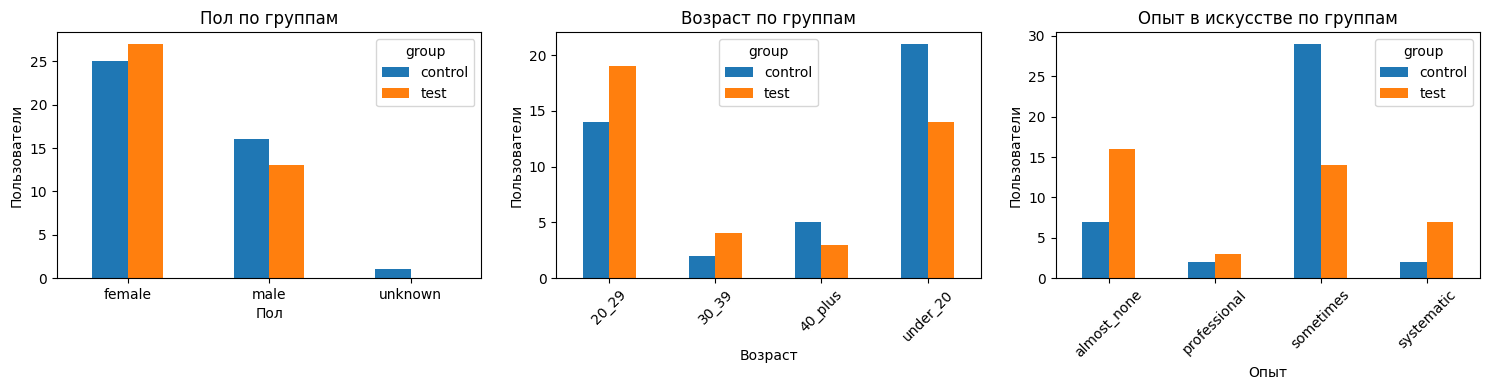

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

pd.crosstab(users['gender'], users['group']).plot(kind='bar', ax=axes[0])
axes[0].set_title('Пол по группам')
axes[0].set_xlabel('Пол')
axes[0].set_ylabel('Пользователи')
axes[0].tick_params(axis='x', rotation=0)

pd.crosstab(users['age_group'], users['group']).plot(kind='bar', ax=axes[1])
axes[1].set_title('Возраст по группам')
axes[1].set_xlabel('Возраст')
axes[1].set_ylabel('Пользователи')
axes[1].tick_params(axis='x', rotation=45)

pd.crosstab(users['art_experience'], users['group']).plot(kind='bar', ax=axes[2])
axes[2].set_title('Опыт в искусстве по группам')
axes[2].set_xlabel('Опыт')
axes[2].set_ylabel('Пользователи')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## 5. Воронка и результаты урока

Помимо survey-оценок, проверяются прохождение урока и количество правильных ответов. Эти показатели помогают понять, не было ли заметных различий в вовлечённости или усвоении материала.


In [9]:
group_funnel = users.groupby('group').agg(
    users=('id', 'count'),
    lesson_started=('started_lesson', 'sum'),
    lesson_completed=('completed_lesson', 'sum'),
    survey_started=('started_survey', 'sum'),
    survey_completed=('completed_survey', 'sum'),
)

for col in ['lesson_started', 'lesson_completed', 'survey_started', 'survey_completed']:
    group_funnel[f'{col}_cr'] = group_funnel[col] / group_funnel['users']

group_funnel.round(3)


,users,lesson_started,lesson_completed,survey_started,survey_completed,lesson_started_cr,lesson_completed_cr,survey_started_cr,survey_completed_cr
group,,,,,,,,,
control,42,40,31,31,31,0.952,0.738,0.738,0.738
test,42,40,33,33,32,0.952,0.786,0.786,0.762


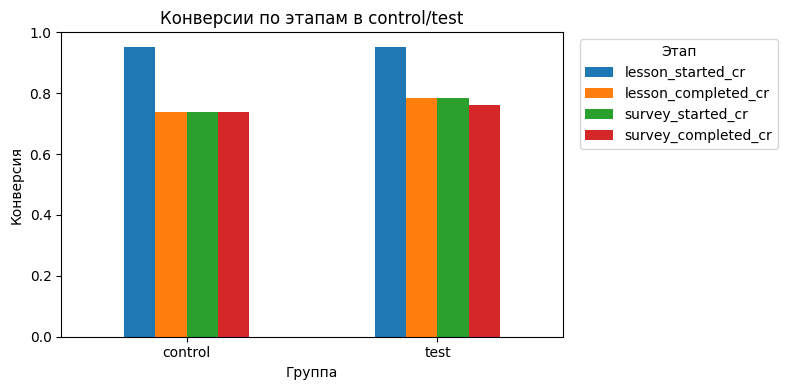

In [10]:
group_funnel[['lesson_started_cr', 'lesson_completed_cr', 'survey_started_cr', 'survey_completed_cr']].plot(kind='bar', figsize=(8, 4))
plt.title('Конверсии по этапам в control/test')
plt.xlabel('Группа')
plt.ylabel('Конверсия')
plt.xticks(rotation=0)
plt.legend(title='Этап', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [11]:
for label, subset in [
    ('все пользователи', users),
    ('только завершившие опрос', users[users['completed_survey']]),
]:
    test = subset.loc[subset['group'] == 'test', 'correct_answers_count'].dropna()
    control = subset.loc[subset['group'] == 'control', 'correct_answers_count'].dropna()
    res = stats.ttest_ind(test, control, equal_var=False)

    print(f'\n=== Correct answers: {label} ===')
    print(subset.groupby('group')['correct_answers_count'].agg(['count', 'mean', 'median', 'std']).round(3))
    print(f'Difference test - control: {test.mean() - control.mean():.3f}')
    print(f'Welch t-test p-value: {res.pvalue:.4f}')



=== Correct answers: все пользователи ===
         count   mean  median    std
group                               
control     42  4.262     6.0  2.651
test        42  4.381     6.0  2.537
Difference test - control: 0.119
Welch t-test p-value: 0.8340

=== Correct answers: только завершившие опрос ===
         count   mean  median    std
group                               
control     31  5.774     6.0  0.762
test        32  5.688     6.0  0.998
Difference test - control: -0.087
Welch t-test p-value: 0.6992


## 6. Подготовка survey-метрики

Если пользователь проходил анкету несколько раз, для анализа берётся последняя полная попытка. Полной считается попытка, в которой есть все вопросы с 1 по 8. Метрика считается на уровне пользователя, чтобы один пользователь не имел большего веса из-за нескольких строк ответов.


In [12]:
def get_last_full_survey_attempts(survey_prepared: pd.DataFrame):
    attempt_summary = (
        survey_prepared.groupby(['telegram_id', 'attempt_n'])
        .agg(
            questions_cnt=('survey_question_number', 'nunique'),
            min_q=('survey_question_number', 'min'),
            max_q=('survey_question_number', 'max'),
            completed_at=('answered_at', 'max'),
        )
        .reset_index()
    )

    full_attempts = attempt_summary[
        (attempt_summary['questions_cnt'] == 8)
        & (attempt_summary['min_q'] == 1)
        & (attempt_summary['max_q'] == 8)
    ].copy()

    last_full_attempts = (
        full_attempts.sort_values(['telegram_id', 'completed_at'])
        .groupby('telegram_id', as_index=False)
        .tail(1)
        .copy()
    )

    df_last = survey_prepared.merge(
        last_full_attempts[['telegram_id', 'attempt_n']],
        on=['telegram_id', 'attempt_n'],
        how='inner',
    ).copy()

    df_last = df_last.sort_values(['telegram_id', 'answered_at', 'survey_question_number']).copy()
    return df_last, full_attempts


def build_user_metric(df_last: pd.DataFrame, users_prepared: pd.DataFrame, target_questions=None) -> pd.DataFrame:
    metric_source = df_last.copy()
    if target_questions is not None:
        metric_source = metric_source[metric_source['survey_question_number'].isin(target_questions)].copy()

    required_questions = 8 if target_questions is None else len(target_questions)
    question_counts = metric_source.groupby('telegram_id')['survey_question_number'].nunique()
    complete_users = question_counts[question_counts == required_questions].index
    metric_source = metric_source[metric_source['telegram_id'].isin(complete_users)].copy()

    users_group = users_prepared[['telegram_id', 'group']].drop_duplicates(subset=['telegram_id'])

    user_metric = (
        metric_source.merge(users_group, on='telegram_id', how='inner')
        .groupby(['telegram_id', 'group'], as_index=False)
        .agg(metric=('selected_option', 'mean'))
    )
    return user_metric

survey_last, full_attempts = get_last_full_survey_attempts(survey)
user_metric_8 = build_user_metric(survey_last, users)
user_metric_127 = build_user_metric(survey_last, users, target_questions=[1, 2, 7])

print('Полных попыток анкеты:', len(full_attempts))
print('Пользователей с последней полной попыткой:', survey_last['telegram_id'].nunique())
print('\nОсновная метрика по 8 вопросам:')
print(user_metric_8['group'].value_counts())
print('\nДополнительная метрика по вопросам 1, 2, 7:')
print(user_metric_127['group'].value_counts())


Полных попыток анкеты: 63
Пользователей с последней полной попыткой: 63

Основная метрика по 8 вопросам:
group
test       32
control    31
Name: count, dtype: int64

Дополнительная метрика по вопросам 1, 2, 7:
group
test       32
control    31
Name: count, dtype: int64


In [13]:
question_check = survey_last.groupby('telegram_id')['survey_question_number'].nunique().value_counts().sort_index()
duplicate_check = (
    survey_last.groupby(['telegram_id', 'attempt_n', 'survey_question_number'])
    .size()
    .reset_index(name='rows')
    .query('rows > 1')
)

print('Распределение числа уникальных вопросов в последней полной попытке:')
print(question_check)
print('\nДубли ответов на один вопрос внутри последней полной попытки:', len(duplicate_check))

survey_last.head(16)


Распределение числа уникальных вопросов в последней полной попытке:
survey_question_number
8    63
Name: count, dtype: int64

Дубли ответов на один вопрос внутри последней полной попытки: 0


,id,telegram_id,survey_question_number,question_text,selected_option,answered_at,is_q1,attempt_n
0,256,129044458,1,"Я чувствовал(а), что меня поддерживают во врем...",10,2026-04-03 16:04:07.908056+00:00,1,1
1,258,129044458,2,В целом взаимодействовать с ботом было приятно,10,2026-04-03 16:04:11.013111+00:00,0,1
2,262,129044458,3,Иногда возникало ощущение более живого взаимод...,10,2026-04-03 16:04:19.331725+00:00,0,1
3,264,129044458,4,"Взаимодействие ощущалось живым, а не формальным",10,2026-04-03 16:04:22.547840+00:00,0,1
4,266,129044458,5,Мне было комфортно проходить урок,10,2026-04-03 16:04:24.508033+00:00,0,1
5,267,129044458,6,"Я не переживал(а), что могу ошибиться",8,2026-04-03 16:04:30.125763+00:00,0,1
6,268,129044458,7,Бот выглядел дружелюбным,10,2026-04-03 16:04:32.795390+00:00,0,1
7,269,129044458,8,Я бы не против(а) пройти что-то подобное ещё раз,10,2026-04-03 16:04:36.052702+00:00,0,1
8,350,193821432,1,"Я чувствовал(а), что меня поддерживают во врем...",10,2026-04-03 17:05:36.424386+00:00,1,1
9,351,193821432,2,В целом взаимодействовать с ботом было приятно,10,2026-04-03 17:05:38.766614+00:00,0,1


## 7. Основная A/B-проверка

Survey-оценки находятся на шкале от 1 до 10 и имеют выраженный потолочный эффект: многие пользователи ставят высокие оценки. Поэтому вместе с t-test дополнительно используется непараметрический Mann-Whitney U test и bootstrap-доверительный интервал для разницы средних.


=== Основная survey-метрика: среднее по 8 вопросам ===
         count    mean  median     std   min   max
group                                             
control     31  8.6371   9.125  1.4395  5.00  10.0
test        32  8.5938   8.750  1.1301  5.25  10.0

Difference test - control: -0.0433 (-0.50%)
Cohen's d: -0.0335
Welch t-test p-value: 0.8949
Mann-Whitney p-value: 0.5217
Bootstrap 95% CI: [-0.6583, 0.6013]
Shapiro control p-value: 0.0005
Shapiro test p-value: 0.0286
Levene p-value: 0.2932


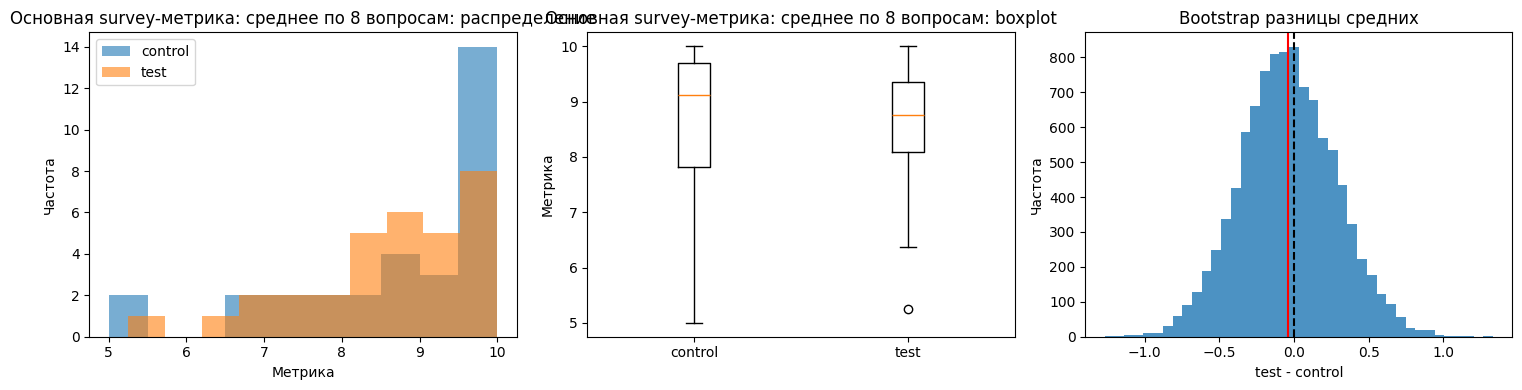

In [14]:
def bootstrap_diff_means(x, y, n_boot=10_000, random_state=42):
    rng = np.random.default_rng(random_state)
    x_vals = np.array(x)
    y_vals = np.array(y)
    diffs = np.empty(n_boot)

    for i in range(n_boot):
        x_boot = rng.choice(x_vals, size=len(x_vals), replace=True)
        y_boot = rng.choice(y_vals, size=len(y_vals), replace=True)
        diffs[i] = x_boot.mean() - y_boot.mean()

    return diffs


def analyze_ab_metric(user_metric: pd.DataFrame, metric_name: str) -> dict:
    test = user_metric.loc[user_metric['group'] == 'test', 'metric'].dropna()
    control = user_metric.loc[user_metric['group'] == 'control', 'metric'].dropna()

    control_mean = control.mean()
    test_mean = test.mean()
    effect_abs = test_mean - control_mean
    effect_pct = effect_abs / control_mean * 100
    std_pooled = np.sqrt((test.std() ** 2 + control.std() ** 2) / 2)
    cohens_d = effect_abs / std_pooled

    welch = stats.ttest_ind(test, control, equal_var=False)
    mannwhitney = stats.mannwhitneyu(test, control, alternative='two-sided')
    shapiro_control = stats.shapiro(control)
    shapiro_test = stats.shapiro(test)
    levene = stats.levene(control, test, center='median')

    boot_diffs = bootstrap_diff_means(test, control)
    ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])

    print(f'=== {metric_name} ===')
    print(user_metric.groupby('group')['metric'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(4))
    print(f'\nDifference test - control: {effect_abs:.4f} ({effect_pct:.2f}%)')
    print(f"Cohen's d: {cohens_d:.4f}")
    print(f'Welch t-test p-value: {welch.pvalue:.4f}')
    print(f'Mann-Whitney p-value: {mannwhitney.pvalue:.4f}')
    print(f'Bootstrap 95% CI: [{ci_low:.4f}, {ci_high:.4f}]')
    print(f'Shapiro control p-value: {shapiro_control.pvalue:.4f}')
    print(f'Shapiro test p-value: {shapiro_test.pvalue:.4f}')
    print(f'Levene p-value: {levene.pvalue:.4f}')

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].hist(control, bins=10, alpha=0.6, label='control')
    axes[0].hist(test, bins=10, alpha=0.6, label='test')
    axes[0].set_title(f'{metric_name}: распределение')
    axes[0].set_xlabel('Метрика')
    axes[0].set_ylabel('Частота')
    axes[0].legend()

    axes[1].boxplot([control, test], tick_labels=['control', 'test'])
    axes[1].set_title(f'{metric_name}: boxplot')
    axes[1].set_ylabel('Метрика')

    axes[2].hist(boot_diffs, bins=40, alpha=0.8)
    axes[2].axvline(0, linestyle='--', color='black')
    axes[2].axvline(effect_abs, linestyle='-', color='red')
    axes[2].set_title('Bootstrap разницы средних')
    axes[2].set_xlabel('test - control')
    axes[2].set_ylabel('Частота')

    plt.tight_layout()
    plt.show()

    return {
        'metric_name': metric_name,
        'n_test': len(test),
        'n_control': len(control),
        'control_mean': control_mean,
        'test_mean': test_mean,
        'effect_abs': effect_abs,
        'effect_pct': effect_pct,
        'cohens_d': cohens_d,
        'welch_p': welch.pvalue,
        'mannwhitney_p': mannwhitney.pvalue,
        'ci_low': ci_low,
        'ci_high': ci_high,
        'std_pooled': std_pooled,
    }

primary_result = analyze_ab_metric(user_metric_8, 'Основная survey-метрика: среднее по 8 вопросам')


## 8. Дополнительная проверка по вопросам 1, 2 и 7

Эта метрика не заменяет основную, а служит проверкой устойчивости вывода на более узком наборе вопросов, связанных с поддержкой, приятностью взаимодействия и дружелюбностью бота.


=== Дополнительная survey-метрика: вопросы 1, 2, 7 ===
         count    mean  median     std     min   max
group                                               
control     31  9.1290  9.6667  1.3297  4.3333  10.0
test        32  9.1979  9.6667  1.0120  6.6667  10.0

Difference test - control: 0.0689 (0.75%)
Cohen's d: 0.0583
Welch t-test p-value: 0.8183
Mann-Whitney p-value: 0.8976
Bootstrap 95% CI: [-0.4805, 0.6620]
Shapiro control p-value: 0.0000
Shapiro test p-value: 0.0000
Levene p-value: 0.7621


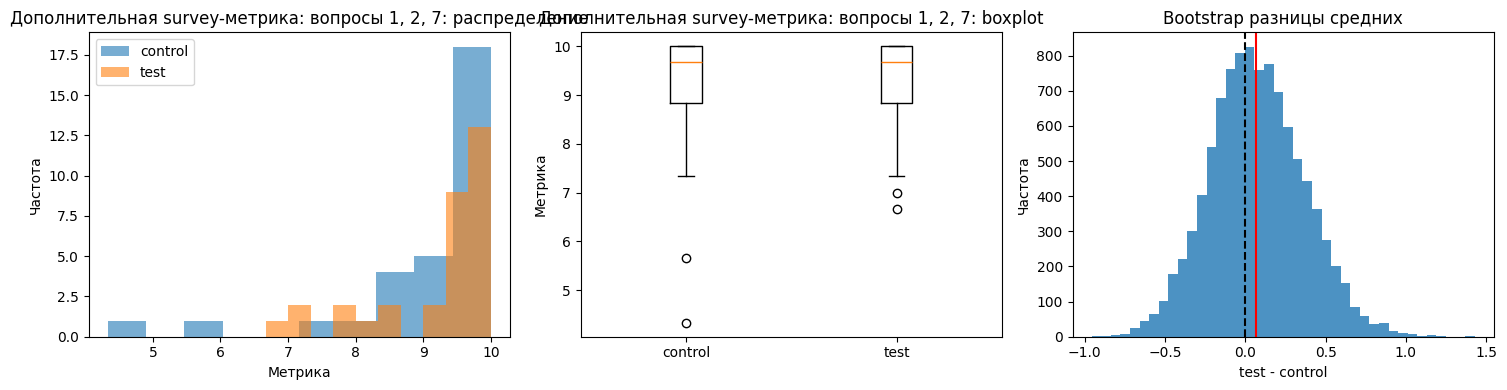

In [15]:
secondary_result = analyze_ab_metric(user_metric_127, 'Дополнительная survey-метрика: вопросы 1, 2, 7')


## 9. Мощность теста и размер выборки

Выборка небольшая, поэтому анализ хорошо обнаруживает только достаточно крупные эффекты. При текущей дисперсии и численности минимальный обнаруживаемый эффект для мощности 80% заметно больше фактически наблюдаемой разницы.

При этом фактическая разница средних очень мала. Поэтому даже если добор выборки увеличил бы статистическую мощность, он вряд ли изменил бы содержательный вывод: наблюдаемый эффект близок к нулю. По этой причине дальнейший добор респондентов в рамках данного исследования не проводится.


In [16]:
def mde_summary(result: dict, alpha=0.05, power=0.8) -> None:
    analysis = TTestIndPower()
    ratio = result['n_control'] / result['n_test']

    detectable_d = analysis.solve_power(
        nobs1=result['n_test'],
        ratio=ratio,
        alpha=alpha,
        power=power,
        alternative='two-sided',
    )

    mde_absolute = detectable_d * result['std_pooled']
    mde_percent = mde_absolute / result['control_mean'] * 100

    print('=== MDE для текущей выборки ===')
    print(f"Test: {result['n_test']}")
    print(f"Control: {result['n_control']}")
    print(f"Detectable Cohen's d: {detectable_d:.3f}")
    print(f'MDE absolute: {mde_absolute:.3f}')
    print(f'MDE percent of control mean: {mde_percent:.2f}%')
    print(f"Observed difference: {result['effect_abs']:.3f}")
    print(f"Observed Cohen's d: {result['cohens_d']:.3f}")

mde_summary(primary_result)


=== MDE для текущей выборки ===
Test: 32
Control: 31
Detectable Cohen's d: 0.717
MDE absolute: 0.928
MDE percent of control mean: 10.75%
Observed difference: -0.043
Observed Cohen's d: -0.033


In [17]:
analysis = TTestIndPower()
ratio = primary_result['n_control'] / primary_result['n_test']

n_test_required = analysis.solve_power(
    effect_size=0.5,
    power=0.8,
    alpha=0.05,
    ratio=ratio,
    alternative='two-sided',
)
n_control_required = n_test_required * ratio

mde_absolute = 0.5 * primary_result['std_pooled']
mde_percent = mde_absolute / primary_result['control_mean'] * 100

print('=== Пример требуемой выборки для среднего эффекта Cohen d = 0.5 ===')
print(f'Test: {int(np.ceil(n_test_required))}')
print(f'Control: {int(np.ceil(n_control_required))}')
print(f'Total: {int(np.ceil(n_test_required + n_control_required))}')
print(f'Абсолютная разница для d=0.5: {mde_absolute:.3f}')
print(f'В процентах от среднего control: {mde_percent:.2f}%')


=== Пример требуемой выборки для среднего эффекта Cohen d = 0.5 ===
Test: 65
Control: 63
Total: 128
Абсолютная разница для d=0.5: 0.647
В процентах от среднего control: 7.49%


## 10. Диагностика выбросов

Выбросы проверяются отдельно для длительностей и для количества правильных ответов. Длительности могут содержать технически объяснимые выбросы: пользователь мог отвлечься, свернуть бот или оставить урок открытым. Эти значения полезно показывать в диагностике, но не стоит удалять автоматически без заранее заданного правила.

Для основной survey-метрики чистка выбросов не применяется: оценки ограничены шкалой от 1 до 10, а большое количество высоких оценок является не ошибкой данных, а потолочным эффектом.


In [18]:
def iqr_outliers(data: pd.DataFrame, col: str):
    s = data[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = data[(data[col] < lower) | (data[col] > upper)].copy()
    stats_dict = {
        'n': len(s),
        'q1': q1,
        'median': s.median(),
        'q3': q3,
        'lower_bound': lower,
        'upper_bound': upper,
        'outliers': len(outliers),
    }
    return outliers, stats_dict

for col in ['lesson_duration_sec', 'survey_duration_sec', 'full_flow_duration_sec', 'correct_answers_count']:
    outliers, stats_dict = iqr_outliers(users, col)
    print(f'\n=== {col} ===')
    print(pd.Series(stats_dict).round(3))
    if not outliers.empty:
        display_cols = ['telegram_id', 'group', col]
        print(outliers[display_cols].sort_values(col).to_string(index=False))



=== lesson_duration_sec ===
n               64.000
q1             133.885
median         197.333
q3             276.355
lower_bound    -79.819
upper_bound    490.060
outliers         5.000
dtype: float64
 telegram_id   group  lesson_duration_sec
  1276717781    test           537.877755
   287800064    test           598.905463
   283560806 control          1270.448710
   972201777    test          1312.674362
  1499119636 control          2039.209570

=== survey_duration_sec ===
n               63.000
q1              33.264
median          41.454
q3              61.931
lower_bound     -9.736
upper_bound    104.931
outliers         6.000
dtype: float64
 telegram_id   group  survey_duration_sec
   970683412    test           110.678461
   418764767 control           117.689122
   682628390    test           118.473285
   896126089 control           125.016939
  7574482457 control           262.571058
   972201777    test           289.222512

=== full_flow_duration_sec ===
n           

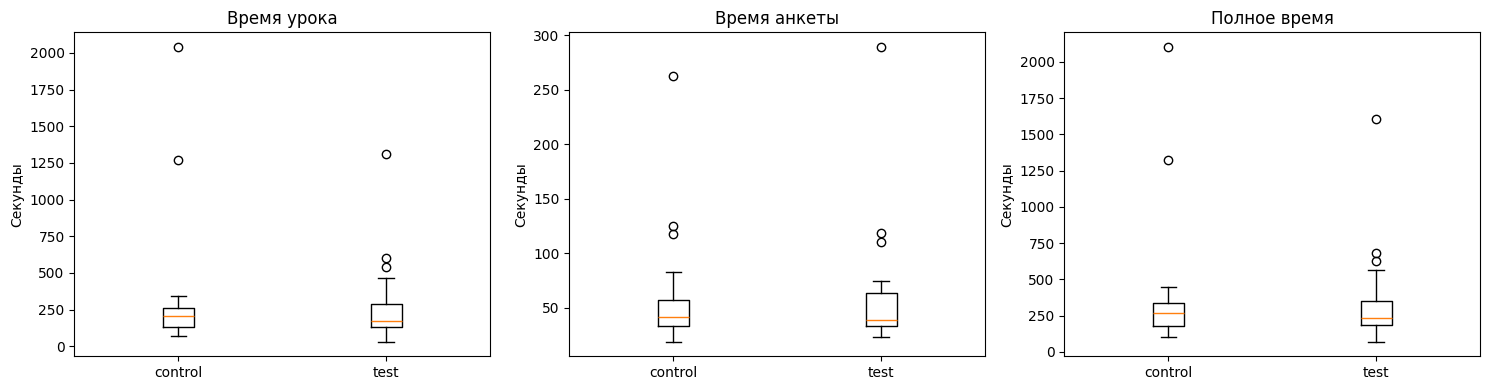

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, title in zip(
    axes,
    ['lesson_duration_sec', 'survey_duration_sec', 'full_flow_duration_sec'],
    ['Время урока', 'Время анкеты', 'Полное время']
):
    plot_data = [
        users.loc[users['group'] == group, col].dropna()
        for group in ['control', 'test']
    ]
    ax.boxplot(plot_data, tick_labels=['control', 'test'])
    ax.set_title(title)
    ax.set_ylabel('Секунды')

plt.tight_layout()
plt.show()


## 11. Сохранение сводных таблиц

Сводные таблицы сохраняются в отдельные CSV-файлы, чтобы их можно было использовать в тексте ВКР или приложениях.


In [20]:
group_summary.to_csv('group_summary.csv')
group_funnel.to_csv('group_funnel.csv')
user_metric_8.to_csv('user_metric_primary_8_questions.csv', index=False)
user_metric_127.to_csv('user_metric_secondary_questions_1_2_7.csv', index=False)
pd.DataFrame([primary_result, secondary_result]).to_csv('ab_test_results.csv', index=False)

print('Сводные таблицы сохранены.')


Сводные таблицы сохранены.


## 12. Итоговый вывод

Тестовая версия бота не показала статистически значимого улучшения по основной survey-метрике. Разница средних между тестовой и контрольной группами близка к нулю, а доверительный интервал включает как небольшой отрицательный, так и небольшой положительный эффект.

Дополнительная проверка по вопросам 1, 2 и 7 приводит к тому же содержательному выводу: статистически значимых различий между группами не обнаружено.

Обе версии получили высокие пользовательские оценки, что указывает на общий положительный пользовательский опыт, но одновременно создаёт потолочный эффект: шкала хуже различает возможные небольшие улучшения. С учётом малого фактического эффекта и обсуждения с научным руководителем добор выборки не проводится, поскольку он вряд ли изменит содержательный вывод исследования.

Ограничения анализа: небольшой размер выборки, потолочный эффект survey-оценок, а также неидеальный баланс групп по возрасту и опыту в искусстве.
